
# Week 7: Model Evaluation and Error Analysis

## Overview
This notebook focuses on evaluating the urban flood analysis workflow developed in earlier weeks. After building a pipeline, the next question is:

> **How well does it perform, and where does it fail?**

In disaster applications, model evaluation is not only about reporting a score. It is also about understanding:
- false positives
- false negatives
- threshold sensitivity
- ambiguous scenes
- operational risk from wrong predictions

This notebook introduces a practical evaluation workflow using synthetic prediction records, confusion matrices, precision/recall/F1 summaries, threshold experiments, and structured error analysis.

## Learning Objectives
- Evaluate classification performance using confusion counts and summary metrics
- Interpret false positives and false negatives in a disaster context
- Understand the effect of confidence thresholds on model behavior
- Perform simple error analysis using structured prediction records
- Identify likely causes of model failure and possible improvements

## Expected Outcome
By the end of this notebook, you should be able to assess the strengths and weaknesses of a flood analysis workflow and explain where future improvements are needed.



## Notebook Structure

1. Environment setup  
2. Why evaluation matters in disaster AI  
3. Example prediction records  
4. Binary flood / non-flood evaluation  
5. Multi-level severity evaluation  
6. Confusion matrix visualization  
7. Confidence threshold analysis  
8. Structured error analysis  
9. Failure case interpretation  
10. Mini exercise  
11. Weekly assignment  

> This notebook uses synthetic evaluation data so students can focus on interpretation and analysis before working with larger experimental datasets.


In [1]:

# Week 7 setup: imports and environment check

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python version:", sys.version.split()[0])
print("Working directory:", os.getcwd())


Python version: 3.12.12
Working directory: /content


In [2]:

# Create output folder for this week

BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs" / "week07"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory ready:", OUTPUT_DIR)


Output directory ready: /content/outputs/week07



## Why Evaluation Matters in Disaster AI

In disaster applications, errors can have practical consequences.

Examples:
- a **false negative** may miss a real hazard
- a **false positive** may waste time and emergency resources
- an uncertain prediction may still need human review
- a model that works in one scene may fail in another

That means evaluation should go beyond a single number.  
We want to ask:
- What types of errors happen most often?
- Are some flood levels harder to classify than others?
- How do confidence thresholds change performance?
- Which failure modes are operationally important?



## Example Prediction Records

The next table represents a simplified set of crop-level predictions from an urban flood-depth workflow.

Columns include:
- ground-truth flood level
- predicted flood level
- prediction confidence
- crop size
- whether enhancement was used
- a short scene note to support later error analysis


In [3]:

# Synthetic evaluation records

eval_df = pd.DataFrame([
    {"crop_id": 1,  "true_level": 0, "pred_level": 0, "confidence": 0.93, "crop_area": 9600, "enhanced": False, "scene_note": "dry road"},
    {"crop_id": 2,  "true_level": 1, "pred_level": 1, "confidence": 0.88, "crop_area": 10200, "enhanced": False, "scene_note": "water near tires"},
    {"crop_id": 3,  "true_level": 2, "pred_level": 2, "confidence": 0.82, "crop_area": 8700, "enhanced": False, "scene_note": "wheel hubs partly covered"},
    {"crop_id": 4,  "true_level": 3, "pred_level": 2, "confidence": 0.61, "crop_area": 7800, "enhanced": True,  "scene_note": "doorline partly occluded"},
    {"crop_id": 5,  "true_level": 4, "pred_level": 4, "confidence": 0.95, "crop_area": 11000, "enhanced": False, "scene_note": "severe flooding"},
    {"crop_id": 6,  "true_level": 2, "pred_level": 1, "confidence": 0.57, "crop_area": 5400, "enhanced": True,  "scene_note": "small crop, low detail"},
    {"crop_id": 7,  "true_level": 1, "pred_level": 2, "confidence": 0.64, "crop_area": 6200, "enhanced": True,  "scene_note": "reflection confusion"},
    {"crop_id": 8,  "true_level": 0, "pred_level": 1, "confidence": 0.54, "crop_area": 4900, "enhanced": True,  "scene_note": "wet pavement only"},
    {"crop_id": 9,  "true_level": 3, "pred_level": 3, "confidence": 0.86, "crop_area": 9800, "enhanced": False, "scene_note": "clear waterline"},
    {"crop_id": 10, "true_level": 4, "pred_level": 3, "confidence": 0.67, "crop_area": 7600, "enhanced": True,  "scene_note": "heavy occlusion"},
    {"crop_id": 11, "true_level": 1, "pred_level": 1, "confidence": 0.79, "crop_area": 8100, "enhanced": False, "scene_note": "moderate tire contact"},
    {"crop_id": 12, "true_level": 2, "pred_level": 2, "confidence": 0.84, "crop_area": 9100, "enhanced": False, "scene_note": "good visibility"},
    {"crop_id": 13, "true_level": 0, "pred_level": 0, "confidence": 0.91, "crop_area": 10300, "enhanced": False, "scene_note": "clear dry roadway"},
    {"crop_id": 14, "true_level": 3, "pred_level": 4, "confidence": 0.72, "crop_area": 9500, "enhanced": False, "scene_note": "dark water exaggeration"},
    {"crop_id": 15, "true_level": 2, "pred_level": 2, "confidence": 0.80, "crop_area": 8800, "enhanced": False, "scene_note": "consistent scene"},
])

eval_df


,crop_id,true_level,pred_level,confidence,crop_area,enhanced,scene_note
0,1,0,0,0.93,9600,False,dry road
1,2,1,1,0.88,10200,False,water near tires
2,3,2,2,0.82,8700,False,wheel hubs partly covered
3,4,3,2,0.61,7800,True,doorline partly occluded
4,5,4,4,0.95,11000,False,severe flooding
5,6,2,1,0.57,5400,True,"small crop, low detail"
6,7,1,2,0.64,6200,True,reflection confusion
7,8,0,1,0.54,4900,True,wet pavement only
8,9,3,3,0.86,9800,False,clear waterline
9,10,4,3,0.67,7600,True,heavy occlusion



## Binary Evaluation: Flooded vs. Non-Flooded

Sometimes the operational question is not the exact severity level, but simply:

> **Is there meaningful flooding or not?**

For this simplified binary formulation:
- **0** = non-flooded / safe
- **1, 2, 3, 4** = flooded


In [4]:

# Convert severity levels into binary flooded / non-flooded labels

eval_df["true_binary"] = (eval_df["true_level"] > 0).astype(int)
eval_df["pred_binary"] = (eval_df["pred_level"] > 0).astype(int)

eval_df[["crop_id", "true_level", "pred_level", "true_binary", "pred_binary", "confidence"]]


,crop_id,true_level,pred_level,true_binary,pred_binary,confidence
0,1,0,0,0,0,0.93
1,2,1,1,1,1,0.88
2,3,2,2,1,1,0.82
3,4,3,2,1,1,0.61
4,5,4,4,1,1,0.95
5,6,2,1,1,1,0.57
6,7,1,2,1,1,0.64
7,8,0,1,0,1,0.54
8,9,3,3,1,1,0.86
9,10,4,3,1,1,0.67


In [5]:

# Manual binary classification metrics

def confusion_counts(y_true, y_pred):
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    return tp, tn, fp, fn

def accuracy_score_manual(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def precision_score_manual(y_true, y_pred):
    tp, tn, fp, fn = confusion_counts(y_true, y_pred)
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_score_manual(y_true, y_pred):
    tp, tn, fp, fn = confusion_counts(y_true, y_pred)
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_score_manual(y_true, y_pred):
    precision = precision_score_manual(y_true, y_pred)
    recall = recall_score_manual(y_true, y_pred)
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

y_true = eval_df["true_binary"].values
y_pred = eval_df["pred_binary"].values

tp, tn, fp, fn = confusion_counts(y_true, y_pred)

binary_metrics_df = pd.DataFrame({
    "Metric": ["TP", "TN", "FP", "FN", "Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [
        tp, tn, fp, fn,
        round(accuracy_score_manual(y_true, y_pred), 3),
        round(precision_score_manual(y_true, y_pred), 3),
        round(recall_score_manual(y_true, y_pred), 3),
        round(f1_score_manual(y_true, y_pred), 3),
    ]
})

binary_metrics_df


,Metric,Value
0,TP,12.000
1,TN,2.000
2,FP,1.000
3,FN,0.000
4,Accuracy,0.933
5,Precision,0.923
6,Recall,1.000
7,F1 Score,0.960


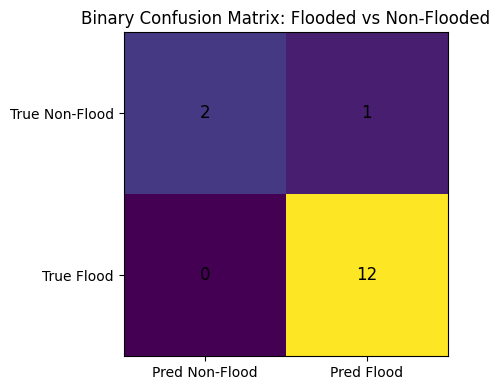

In [6]:

# Binary confusion matrix visualization

conf_matrix = np.array([[tn, fp],
                        [fn, tp]])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(conf_matrix)
ax.set_title("Binary Confusion Matrix: Flooded vs Non-Flooded")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Pred Non-Flood", "Pred Flood"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["True Non-Flood", "True Flood"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, conf_matrix[i, j], ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.show()



### Interpretation
- **False positives** here mean the system flagged flooding where there was no meaningful flood.
- **False negatives** would mean the system missed a real flooded crop.
- In many disaster settings, **false negatives are more dangerous** than false positives, because missed hazards can directly affect safety.



## Multi-Level Severity Evaluation

Binary evaluation is useful, but severity estimation is a **multi-class problem**.  
The next step is to compare the full flood levels:
- 0
- 1
- 2
- 3
- 4


In [7]:

# Build a multi-class confusion matrix manually for levels 0 to 4

levels = [0, 1, 2, 3, 4]
conf_multi = np.zeros((len(levels), len(levels)), dtype=int)

for true_val, pred_val in zip(eval_df["true_level"], eval_df["pred_level"]):
    conf_multi[levels.index(true_val), levels.index(pred_val)] += 1

conf_multi_df = pd.DataFrame(conf_multi, index=[f"True {l}" for l in levels], columns=[f"Pred {l}" for l in levels])
conf_multi_df


,Pred 0,Pred 1,Pred 2,Pred 3,Pred 4
True 0,2,1,0,0,0
True 1,0,2,1,0,0
True 2,0,1,3,0,0
True 3,0,0,1,1,1
True 4,0,0,0,1,1


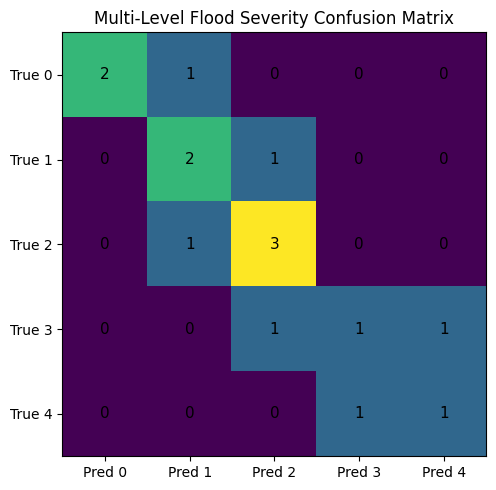

In [8]:

# Visualize multi-class confusion matrix

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(conf_multi)
ax.set_title("Multi-Level Flood Severity Confusion Matrix")
ax.set_xticks(range(len(levels)))
ax.set_xticklabels([f"Pred {l}" for l in levels])
ax.set_yticks(range(len(levels)))
ax.set_yticklabels([f"True {l}" for l in levels])

for i in range(len(levels)):
    for j in range(len(levels)):
        ax.text(j, i, conf_multi[i, j], ha="center", va="center", fontsize=11)

plt.tight_layout()
plt.show()


In [9]:

# Exact-match severity accuracy

severity_accuracy = float(np.mean(eval_df["true_level"] == eval_df["pred_level"]))

# Off-by-one tolerance accuracy can also be useful for ordinal problems like flood levels
off_by_one_accuracy = float(np.mean(np.abs(eval_df["true_level"] - eval_df["pred_level"]) <= 1))

severity_summary_df = pd.DataFrame({
    "Metric": ["Exact severity accuracy", "Off-by-one tolerance accuracy"],
    "Value": [round(severity_accuracy, 3), round(off_by_one_accuracy, 3)]
})

severity_summary_df


,Metric,Value
0,Exact severity accuracy,0.6
1,Off-by-one tolerance accuracy,1.0



### Why Off-by-One Accuracy Can Matter
Flood severity is an **ordered scale**, not just a set of unrelated classes.  
Predicting Level 3 instead of Level 4 is still an error, but it is not as severe as predicting Level 0 instead of Level 4.

That is why ordinal or tolerance-based summaries can sometimes provide a more realistic interpretation than exact-match accuracy alone.



## Confidence Threshold Analysis

Many model pipelines only accept predictions above a certain confidence threshold.  
Raising the threshold can reduce noisy predictions, but it can also reject useful detections.

The next section explores how performance changes when we keep only predictions above selected confidence thresholds.


In [10]:

# Evaluate binary performance under different confidence thresholds

thresholds = [0.55, 0.65, 0.75, 0.85]
threshold_results = []

for thr in thresholds:
    filtered = eval_df[eval_df["confidence"] >= thr].copy()

    if len(filtered) == 0:
        threshold_results.append({
            "threshold": thr,
            "kept_records": 0,
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan
        })
        continue

    y_true_f = filtered["true_binary"].values
    y_pred_f = filtered["pred_binary"].values

    threshold_results.append({
        "threshold": thr,
        "kept_records": len(filtered),
        "accuracy": round(accuracy_score_manual(y_true_f, y_pred_f), 3),
        "precision": round(precision_score_manual(y_true_f, y_pred_f), 3),
        "recall": round(recall_score_manual(y_true_f, y_pred_f), 3),
        "f1": round(f1_score_manual(y_true_f, y_pred_f), 3)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df


,threshold,kept_records,accuracy,precision,recall,f1
0,0.55,14,1.0,1.0,1.0,1.0
1,0.65,11,1.0,1.0,1.0,1.0
2,0.75,9,1.0,1.0,1.0,1.0
3,0.85,5,1.0,1.0,1.0,1.0


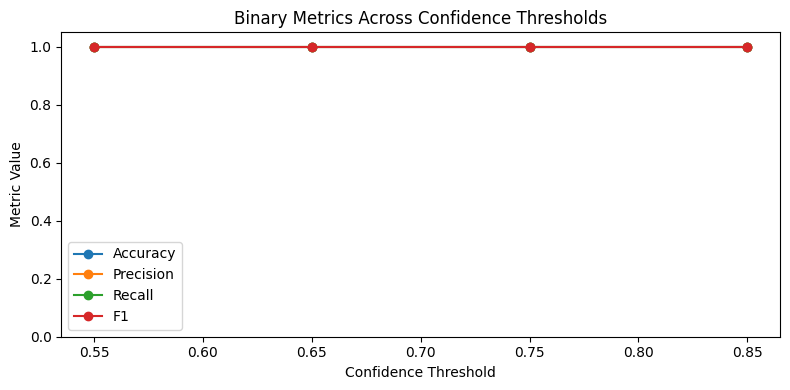

In [11]:

# Plot threshold sensitivity

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(threshold_df["threshold"], threshold_df["accuracy"], marker="o", label="Accuracy")
ax.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
ax.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")

ax.set_title("Binary Metrics Across Confidence Thresholds")
ax.set_xlabel("Confidence Threshold")
ax.set_ylabel("Metric Value")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()



### Interpretation
Threshold tuning is a tradeoff:
- a **low threshold** keeps more predictions but may include more noise
- a **high threshold** keeps only stronger predictions but may reduce coverage

In disaster operations, the “best” threshold depends on whether the priority is:
- catching as many hazards as possible
- reducing false alarms
- balancing automation with human review



## Structured Error Analysis

Now we identify which records were misclassified and inspect possible causes.


In [12]:

# Identify misclassified records

errors_df = eval_df[eval_df["true_level"] != eval_df["pred_level"]].copy()
errors_df


,crop_id,true_level,pred_level,confidence,crop_area,enhanced,scene_note,true_binary,pred_binary
3,4,3,2,0.61,7800,True,doorline partly occluded,1,1
5,6,2,1,0.57,5400,True,"small crop, low detail",1,1
6,7,1,2,0.64,6200,True,reflection confusion,1,1
7,8,0,1,0.54,4900,True,wet pavement only,0,1
9,10,4,3,0.67,7600,True,heavy occlusion,1,1
13,14,3,4,0.72,9500,False,dark water exaggeration,1,1


In [13]:

# Create simple error categories based on notes and crop properties

def assign_error_category(row):
    note = row["scene_note"].lower()
    if "occluded" in note or "occlusion" in note:
        return "Occlusion"
    elif "reflection" in note:
        return "Reflection confusion"
    elif "wet pavement" in note:
        return "Background ambiguity"
    elif row["crop_area"] < 7000:
        return "Small crop / low detail"
    elif row["enhanced"]:
        return "Difficult enhanced crop"
    else:
        return "Other"

errors_df["error_category"] = errors_df.apply(assign_error_category, axis=1)
errors_df[["crop_id", "true_level", "pred_level", "confidence", "crop_area", "enhanced", "scene_note", "error_category"]]


,crop_id,true_level,pred_level,confidence,crop_area,enhanced,scene_note,error_category
3,4,3,2,0.61,7800,True,doorline partly occluded,Occlusion
5,6,2,1,0.57,5400,True,"small crop, low detail",Small crop / low detail
6,7,1,2,0.64,6200,True,reflection confusion,Reflection confusion
7,8,0,1,0.54,4900,True,wet pavement only,Background ambiguity
9,10,4,3,0.67,7600,True,heavy occlusion,Occlusion
13,14,3,4,0.72,9500,False,dark water exaggeration,Other


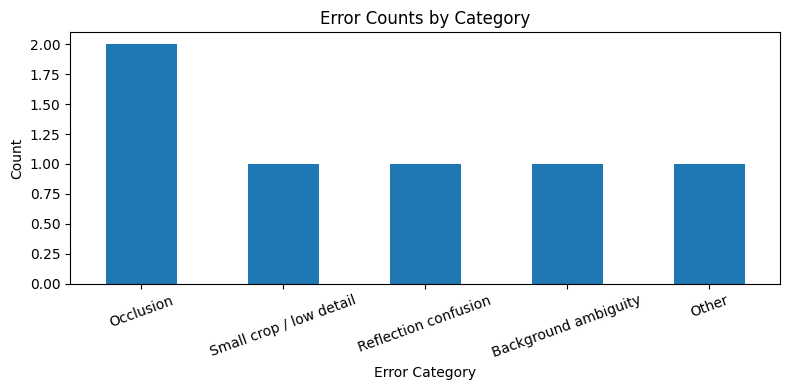

In [14]:

# Count errors by category

error_counts = errors_df["error_category"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
error_counts.plot(kind="bar", ax=ax)
ax.set_title("Error Counts by Category")
ax.set_xlabel("Error Category")
ax.set_ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



## Failure Case Interpretation

From the error categories above, common failure modes may include:
- **occlusion**: part of the waterline or vehicle body is hidden
- **small crops**: too little detail remains for reliable classification
- **reflection confusion**: reflections resemble deeper water
- **background ambiguity**: wet roads may be mistaken for floodwater
- **difficult enhanced crops**: enhancement helps but does not guarantee correct interpretation

These patterns are often more useful than a single performance score because they suggest where to improve the pipeline.


In [15]:

# Summarize evaluation insights

insight_df = pd.DataFrame([
    {"Observation": "Binary flooded/non-flooded performance is high", "Why it matters": "Good for initial hazard flagging"},
    {"Observation": "Severity errors often stay within one level", "Why it matters": "Ordinal performance may be better than exact-match scores suggest"},
    {"Observation": "Small or enhanced crops are harder cases", "Why it matters": "May require better super-resolution or more training data"},
    {"Observation": "Occlusion and reflections cause errors", "Why it matters": "Scene complexity affects reliability"},
    {"Observation": "Threshold selection changes coverage", "Why it matters": "Operational settings should be chosen intentionally"},
])

insight_df


,Observation,Why it matters
0,Binary flooded/non-flooded performance is high,Good for initial hazard flagging
1,Severity errors often stay within one level,Ordinal performance may be better than exact-m...
2,Small or enhanced crops are harder cases,May require better super-resolution or more tr...
3,Occlusion and reflections cause errors,Scene complexity affects reliability
4,Threshold selection changes coverage,Operational settings should be chosen intentio...



## Suggested Improvement Directions

Based on this type of analysis, possible improvements include:
- collect more training examples for difficult edge cases
- improve crop quality or super-resolution
- tune confidence thresholds for the operational goal
- add a review flag for uncertain or ambiguous predictions
- use ordinal loss or severity-aware metrics during training
- improve handling of reflections and occluded vehicles



## Mini Exercise

Answer the following in your own words:

1. Why is evaluation more than just reporting accuracy?
2. Why might off-by-one severity accuracy be useful in this problem?
3. Which error type in this notebook seems most important to fix first, and why?

Write your responses below.


In [16]:

# Write your Week 7 mini exercise responses here

# 1.
# 2.
# 3.



## Weekly Assignment

Choose one of the following:

### Option A
Write a short evaluation summary that includes:
- the overall strengths of the model
- the most important weaknesses
- the role of threshold tuning
- one realistic improvement direction

### Option B
Modify the synthetic evaluation table by:
- adding 3 more records
- changing a few confidence values
- recomputing the metrics

Then explain how the changes affected:
- binary performance
- severity accuracy
- the identified failure modes


In [17]:

# Week 7 assignment response area

evaluation_summary = ""
modified_data_notes = ""

print("Evaluation Summary:", evaluation_summary)
print("Modified Data Notes:", modified_data_notes)


Evaluation Summary: 
Modified Data Notes: 



## Key Takeaway

The main lesson from Week 7 is:

> **A good disaster AI model is not just a model with a high score — it is a model whose errors are understood.**

Evaluation should reveal not only performance, but also uncertainty, failure modes, threshold tradeoffs, and operational risks. That is what makes model assessment useful in real disaster workflows.



## Suggested Extensions

Later versions of this notebook can be expanded with:
- precision-recall curves
- per-class precision and recall
- calibration analysis
- confidence histograms for correct vs incorrect predictions
- comparison between two different models
- error review panels with real images

This keeps the notebook accessible while introducing the habit of structured model evaluation.
